<div align="center">

<p style="font-size:42px; margin-bottom:8px;">
    <strong><span style="color:#2563EB;">AI TalentScout</span></strong>
</p>

<p style="font-size:20px; color:#6B7280;">
    <strong>Intelligent Resume Screening &amp; Candidate Ranking System</strong>
</p>

</div>


## <strong><span style="color:#2563EB;">AI Resume Screening & Candidate Ranking System</span></strong>

An <strong>end-to-end Machine Learning application</strong> that predicts whether a <strong>job candidate</strong> should be <span style="background-color:#DDEBFF;"><strong>shortlisted</strong></span> based on <strong>resume-related information</strong> and <span style="background-color:#FFF3B0;"><strong>ranks candidates</strong></span> according to their <strong>predicted suitability score</strong>. The project includes <strong>data preprocessing</strong>, <strong>exploratory data analysis (EDA)</strong>, <strong>feature engineering</strong>, <strong>model comparison</strong>, <strong>model evaluation</strong>, and an <strong>interactive Streamlit web application</strong> for <strong>real-time predictions</strong> and <strong>candidate ranking</strong>.


## <strong><span style="color:#2563EB;">Use Case</span></strong>

Recruiters often receive <strong>hundreds of job applications</strong> for a single position. Manually reviewing every <strong>resume</strong> is <span style="background-color:#FFE4E6;"><strong>time-consuming</strong></span> and <span style="background-color:#FFE4E6;"><strong>inconsistent</strong></span>. This system helps <strong>recruiters</strong> by automatically <span style="background-color:#DDEBFF;"><strong>evaluating candidate profiles</strong></span>, <span style="background-color:#FFF3B0;"><strong>predicting their likelihood of being shortlisted</strong></span>, <strong>ranking applicants</strong> based on <strong>model confidence</strong>, and enabling <strong>faster</strong>, <strong>data-driven hiring decisions</strong>.


In [ ]:
#lets start 

In [35]:
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning 
        ↓
Handle Outliers (if required)
        ↓
Exploratory Data Analysis (EDA)
        ↓
Feature Engineering
        ↓
Encoding
        ↓
Define X and y
        ↓
Train-Test Split
        ↓
Feature Scaling (if required)
        ↓
(Optional) PCA / Feature Selection
        ↓
Train Multiple Models
        ↓
Cross Validation
        ↓
Hyperparameter Tuning
        ↓
Final Model Selection
        ↓
Evaluation on Test Set
        ↓
Save Model
        ↓
Deployment (Streamlit)
        ↓
GitHub + README

In [36]:
data = pd.read_csv(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\AI Resume Screening & Candidate Ranking System\dataset\resume_dataset_200k_enhanced.csv")


df = pd.DataFrame(data)

In [ ]:
#data understanding

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df['company_type'].value_counts()

In [ ]:
df.columns

In [17]:
df.shape

(200000, 17)

<h2 style="font-size:30px; color:#374151;">
    <strong>Target Variable</strong>
</h2>

<p>
In this dataset, the <strong><span style="color:#4F46E5;">Hired</span></strong> column represents the <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>target variable</strong></span>.
</p>

<p>➦ <span style="background-color:#FFE4E6; padding:2px 6px; border-radius:4px;"><strong>0 = Not Hired</strong></span></p>

<p>➦ <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>1 = Hired</strong></span></p>

<h2 style="font-size:30px; color:#374151;">
    <strong>Observations</strong>
</h2>

<p>➦ <strong>No null values</strong> found.</p>

<p>➦ Only <strong><span style="color:#0F766E;">candidate_id</span></strong> is <strong>individual column</strong> i will <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>drop</strong></span> before <strong>model training</strong>.</p>

<p>➦ <strong>Age limit</strong> of candidates is : <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>21-34 years old</strong></span>.</p>

<p>➦ <strong><span style="color:#4F46E5;">Education_level</span></strong>, <strong><span style="color:#4F46E5;">University_type</span></strong> and <strong><span style="color:#4F46E5;">Company_type</span></strong> are the columns i need to <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>encode</strong></span> before proceeding to <strong>model training</strong>.</p>

In [ ]:
#data cleaning

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

<h2 style="font-size:30px; color:#374151;">
    <strong>Observations</strong>
</h2>

<p>➦ <strong>No null values</strong> found.</p>

<p>➦ <strong>No duplicate rows</strong> found.</p>

<p>
<strong>That means</strong> i am <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>ready to go on to the next step</strong></span>.
</p>

In [ ]:
# Handle Outliers

In [ ]:
df.sample()

In [ ]:
#plotting boxplots to check outliers for numerical columns

numerical_columns = df.select_dtypes(include="number").drop(columns=["candidate_id"]).columns

for column in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

<h2 style="font-size:30px; color:#374151;">
    <strong>Observation</strong>
</h2>

<p>
➦ Although <strong>outliers</strong> are present in the <strong><span style="color:#4F46E5;">CGPA</span></strong>, <strong><span style="color:#4F46E5;">Internships</span></strong>, <strong><span style="color:#4F46E5;">Projects</span></strong>, and <strong><span style="color:#4F46E5;">Certifications</span></strong> features, they represent <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>realistic candidate profiles</strong></span> rather than <strong>data entry errors</strong>; therefore, <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>no outlier treatment</strong></span> was performed, and <strong>all observations</strong> were retained for <strong>model training</strong>.
</p>

In [6]:
#Exploratory Data Analysis(EDA)

In [13]:
#lets plot some graphs 


df.sample(12)

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
85288,85289,21,Bachelors,Tier 1,8.21,0,2,3,1,0.40,0,0,11.5,0,9.60,412,Startup
39065,39066,23,Bachelors,Tier 2,7.70,3,3,3,2,1.89,1,1,16.0,0,8.82,728,MNC
8005,8006,25,Bachelors,Tier 1,7.27,1,4,3,1,6.72,2,0,17.5,1,5.55,559,Mid-size
189615,189616,28,Bachelors,Tier 2,7.43,2,3,4,1,1.65,0,0,15.5,1,5.77,479,Startup
37793,37794,32,PhD,Tier 2,6.95,1,6,1,2,0.43,1,0,18.0,0,9.06,499,Startup
28600,28601,24,Bachelors,Tier 1,7.47,1,5,3,1,0.07,1,0,18.5,0,7.59,463,Mid-size
175187,175188,21,Masters,Tier 2,7.12,0,3,5,2,8.02,0,0,19.0,1,9.21,355,Mid-size
88535,88536,33,Bachelors,Tier 1,7.57,1,4,2,1,0.74,1,0,14.5,1,9.73,285,MNC
61523,61524,29,PhD,Tier 2,7.70,4,4,5,2,1.52,0,0,21.0,0,9.21,353,Mid-size
145259,145260,23,Bachelors,Tier 2,8.17,0,4,1,1,3.31,1,1,12.5,1,6.77,255,MNC


C:\Users\shobh\AppData\Local\Temp\ipykernel_17528\1005960405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


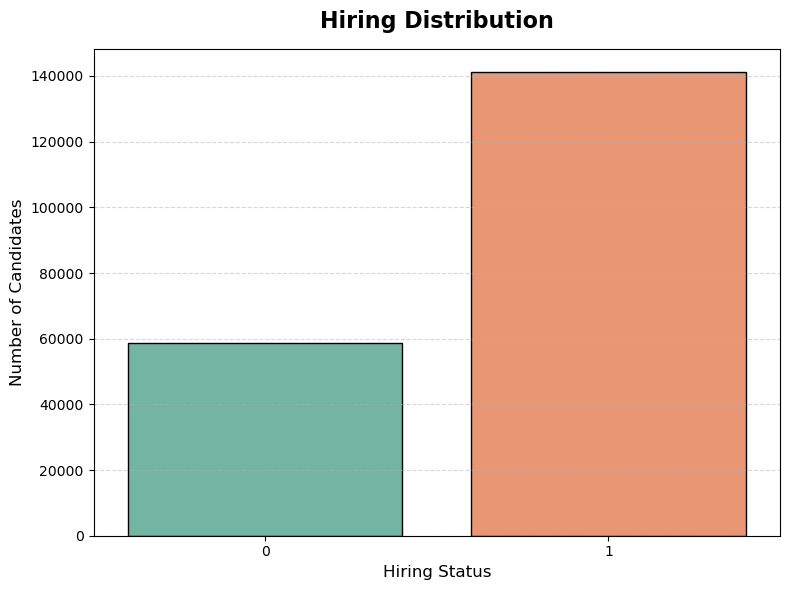

In [25]:
# Hiring Distribution

plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x="hired",palette="Set2",edgecolor="black")

plt.title("Hiring Distribution", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Hiring Status", fontsize=12)
plt.ylabel("Number of Candidates", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\AI Resume Screening & Candidate Ranking System\graphs\Hiring Distribution.png",
    dpi=300, bbox_inches="tight")

plt.show()

<h2 style="font-size:30px; color:#374151;">
    <strong>Observation</strong>
</h2>

<p>➦ The number of people who get <strong>hired</strong> is greater than the number of people who <strong>dont</strong>.</p>

<p>➦ Over <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>2 Lakhs</strong></span> applicant only <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>1.4L</strong></span> candidates got selected.</p>

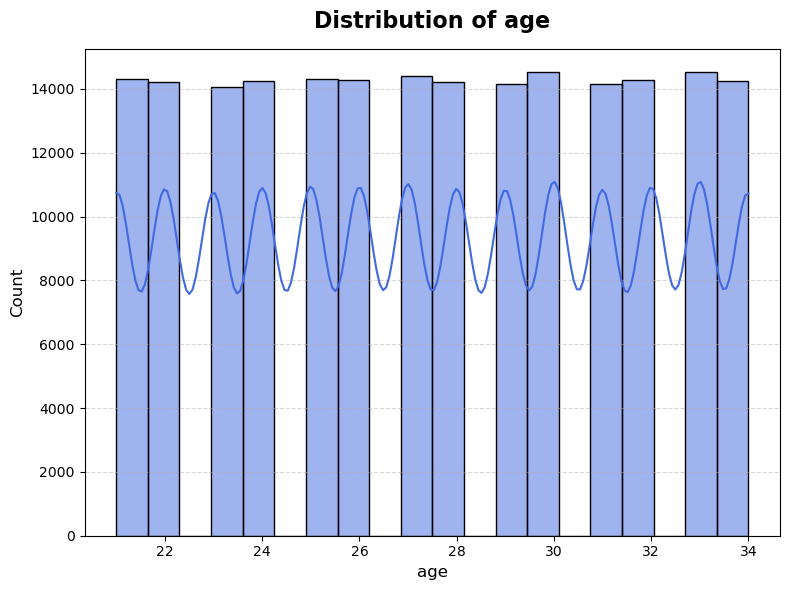

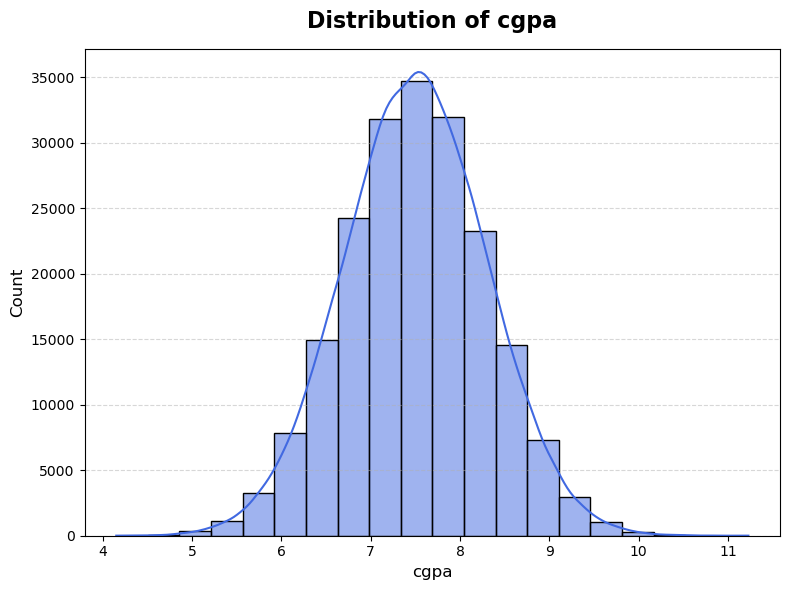

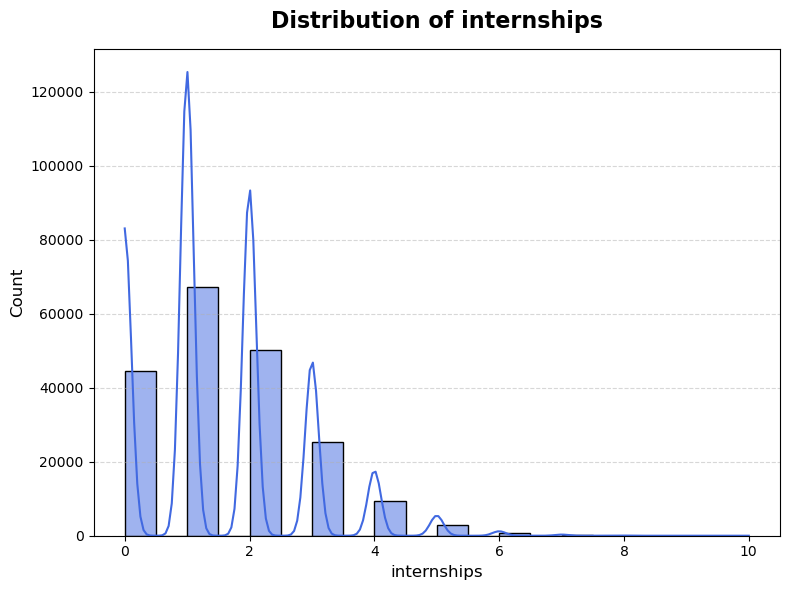

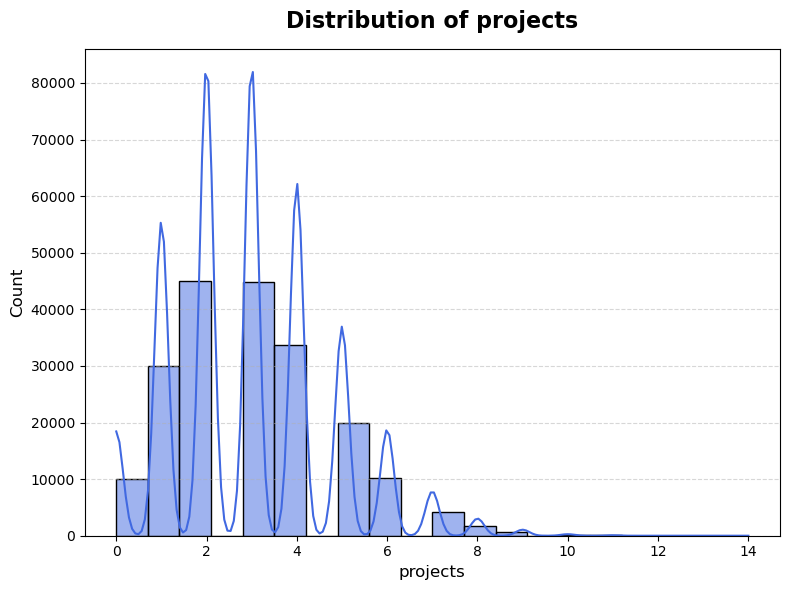

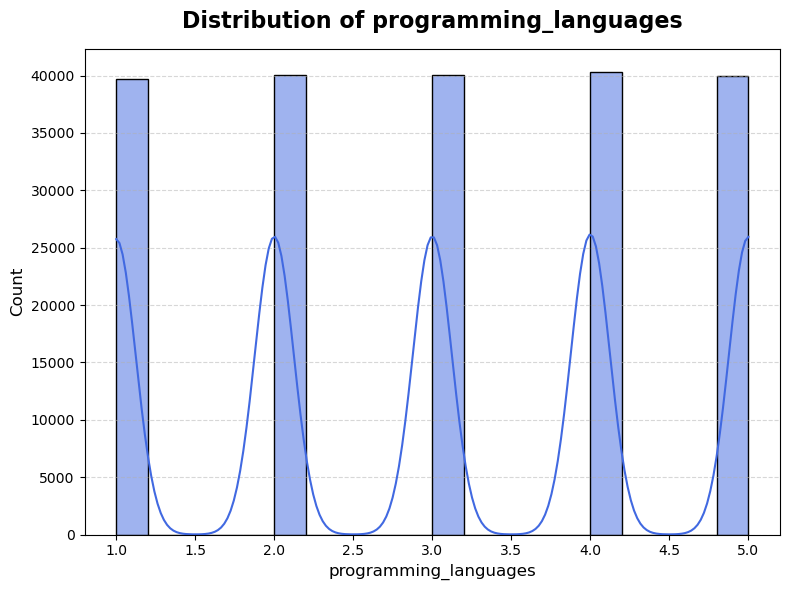

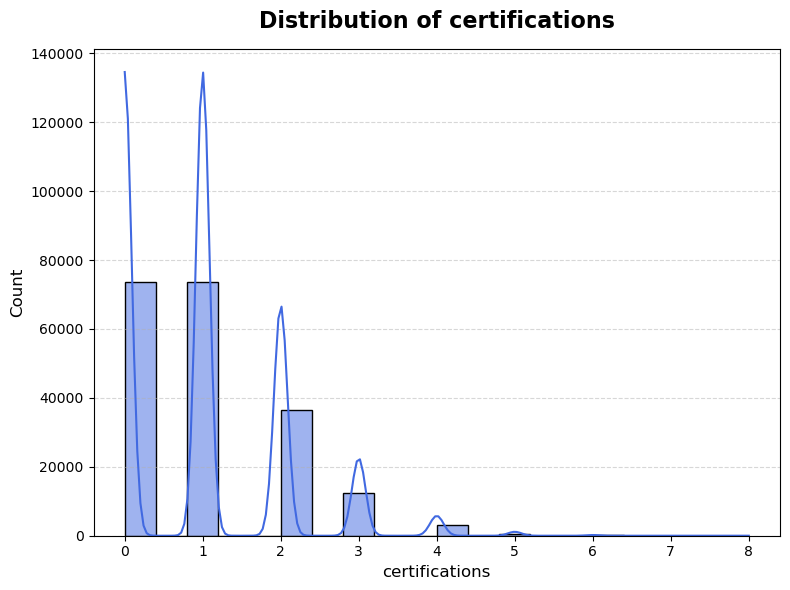

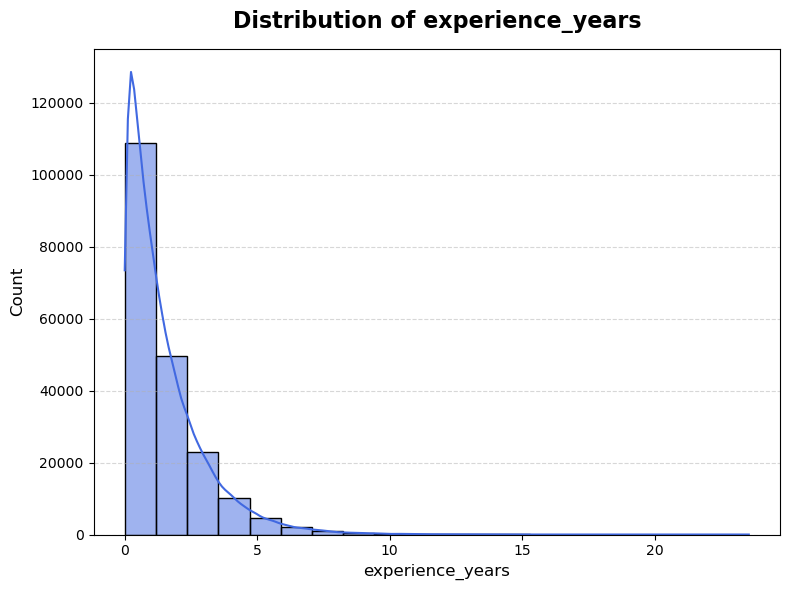

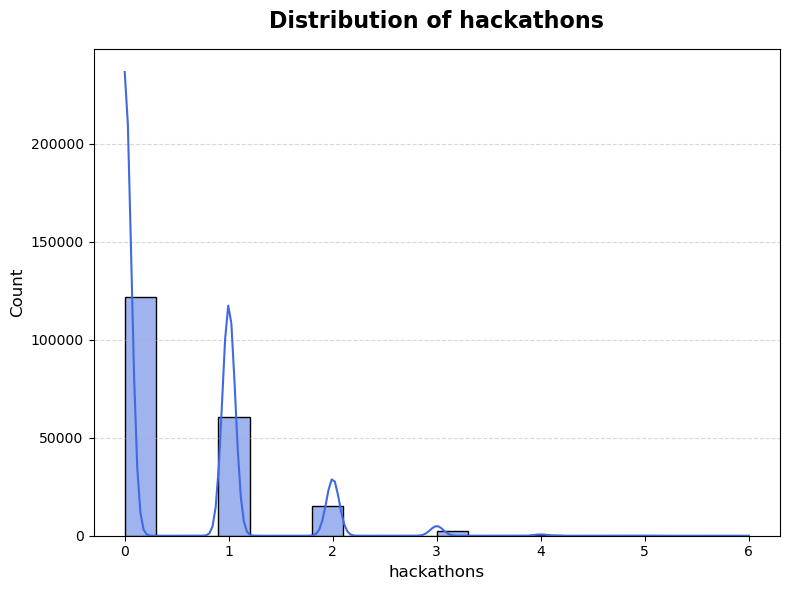

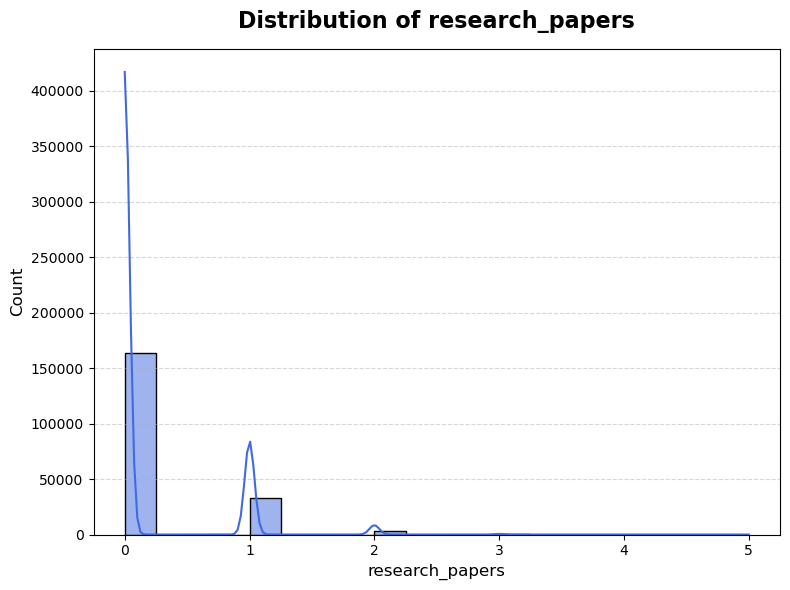

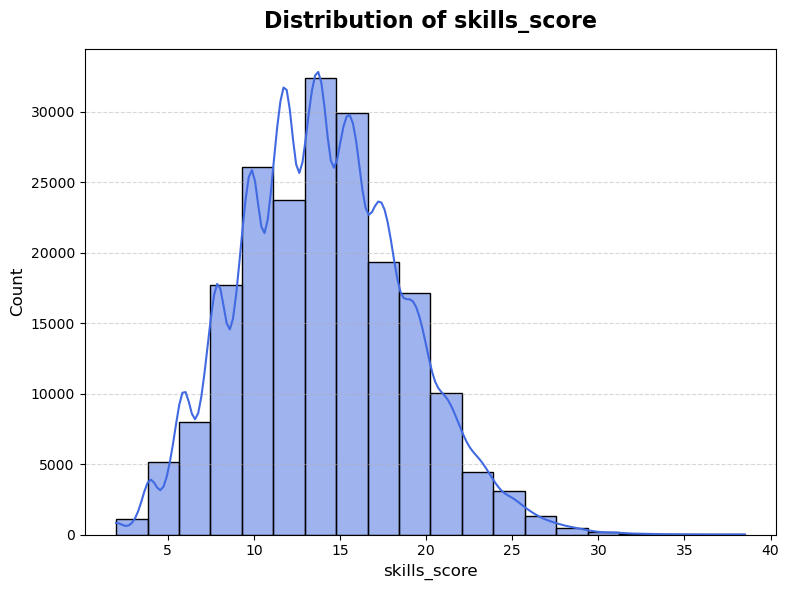

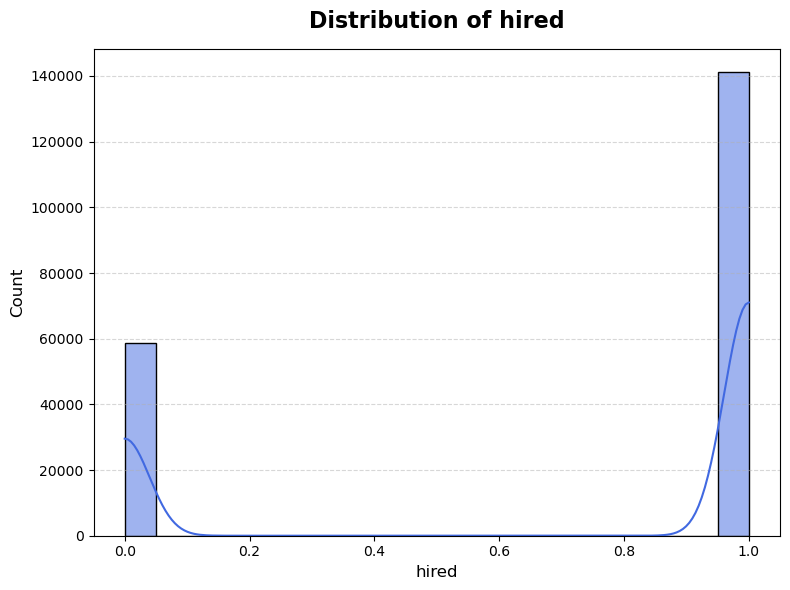

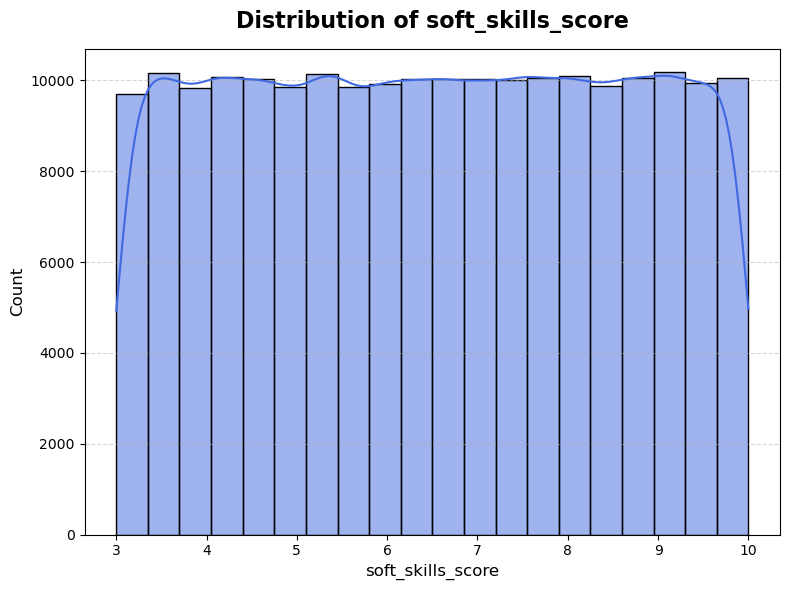

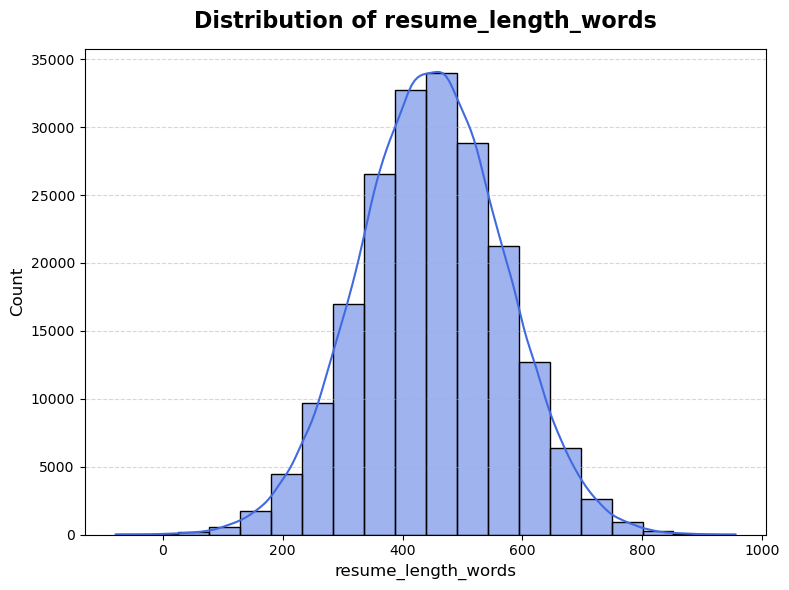

In [32]:
# Histograms to Understand the Distribution of Numerical Columns

save_path = r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\AI Resume Screening & Candidate Ranking System\graphs"
numeric_cols = df.select_dtypes("number").drop(columns=["candidate_id"]).columns

for column in numeric_cols:

    plt.figure(figsize=(8, 6))

    sns.histplot(
        data=df,
        x=column,
        bins=20,
        color="royalblue",
        edgecolor="black",
        kde=True
    )

    plt.title(f"Distribution of {column}", fontsize=16, fontweight="bold", pad=15)

    plt.xlabel(column, fontsize=12)

    plt.ylabel("Count", fontsize=12)

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()

    plt.savefig(
        os.path.join(save_path, f"{column}_Distribution.png"),
        dpi=300, bbox_inches="tight")

    plt.show()

<h2 style="font-size:30px; color:#374151;">
    <strong>Final Observation</strong>
</h2>

<h3><strong>Age</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ The age distribution is nearly uniform between <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>21 and 34 years</strong></span>, indicating that applicants from all age groups are almost equally represented.</p>

<h3><strong>CGPA</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ The <strong>CGPA</strong> follows an approximately <strong>normal (bell-shaped)</strong> distribution, with most candidates having a <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>CGPA between 6.5 and 8.5</strong></span>.</p>

<p>➦ Very low and very high <strong>CGPA</strong> values are comparatively less frequent.</p>

<h3><strong>Internships</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ Most candidates have <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>1–2 internships</strong></span>, while the number of candidates decreases as internship count increases.</p>

<p>➦ Candidates with more than <strong>5 internships</strong> are relatively rare.</p>

<h3><strong>Projects</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ Most applicants have completed <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>2–4 projects</strong></span>, indicating moderate project experience among the majority of candidates.</p>

<p>➦ Candidates with a very high number of projects are uncommon.</p>

<h3><strong>Programming Languages</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ The number of <strong>programming languages</strong> known is almost evenly distributed between <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>1 and 5</strong></span>, suggesting balanced representation across all categories.</p>

<h3><strong>Certifications</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ Most candidates possess <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>0–2 certifications</strong></span>.</p>

<p>➦ The frequency decreases significantly as the number of certifications increases.</p>

<h3><strong>Experience Years</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ The distribution is highly <strong>right-skewed</strong>, indicating that most applicants have <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>less than 5 years of experience</strong></span>.</p>

<p>➦ Candidates with extensive experience are comparatively few.</p>

<h3><strong>Hackathons</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ The majority of applicants have participated in <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>0 or 1 hackathon</strong></span>.</p>

<p>➦ Participation beyond <strong>2 hackathons</strong> is relatively uncommon.</p>

<h3><strong>Research Papers</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ Most candidates have <strong>no published research papers</strong>.</p>

<p>➦ Only a small proportion of applicants have <strong>one or more research publications</strong>.</p>

<h3><strong>Skills Score</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ The <strong>skills score</strong> is concentrated between <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>10 and 18</strong></span>, with fewer candidates having extremely low or very high scores.</p>

<p>➦ The distribution is slightly <strong>right-skewed</strong>.</p>

<h3><strong>Hired</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ The number of <strong>hired candidates</strong> is greater than the number of <strong>non-hired candidates</strong>.</p>

<p>➦ The dataset shows a moderate <strong>class imbalance</strong> in favor of hired applicants.</p>

<h3><strong>Soft Skills Score</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ The <strong>soft skills score</strong> is almost uniformly distributed between <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>3 and 10</strong></span>, indicating balanced representation across different score levels.</p>

<h3><strong>Resume Length (Words)</strong></h3>

<p><strong>Observation :</strong></p>

<p>➦ <strong> I got no observation </strong>

In [ ]:
#feature engineering is already done so next step is : encoding

In [37]:
df.sample(6)

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
114192,114193,23,Bachelors,Tier 1,7.42,1,3,4,1,1.44,0,0,15.5,0,9.24,351,Startup
189678,189679,27,Bachelors,Tier 3,6.69,2,2,1,1,0.46,1,1,8.5,1,4.40,640,Mid-size
78270,78271,21,Bachelors,Tier 1,8.01,1,0,1,1,0.90,0,0,3.5,1,9.19,476,MNC
146807,146808,33,Masters,Tier 3,7.17,2,2,4,4,0.04,1,0,19.0,1,4.13,510,Startup
54716,54717,21,Masters,Tier 2,5.99,2,5,5,0,1.58,1,2,21.0,1,6.86,178,MNC
123606,123607,25,Bachelors,Tier 2,8.36,3,3,5,1,0.87,0,0,17.5,1,3.01,298,MNC


<h2 style="font-size:30px; color:#374151;">
    <strong>Observations :</strong>
</h2>

<p>
➦ From the dataset firstly we will <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>drop</strong></span> column <strong>id</strong> beacuse its meaningless to add column <strong>id</strong> into <strong>features</strong> for <strong>model training</strong>.
</p>

<p>
➦ Columns i feel need <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>encoding</strong></span> before <strong>model training</strong> is :
</p>

<p><strong>1.</strong> <span style="color:#4F46E5;"><strong>education_level</strong></span></p>

<p><strong>2.</strong> <span style="color:#4F46E5;"><strong>university_tier</strong></span></p>

<p><strong>3.</strong> <span style="color:#4F46E5;"><strong>company_type</strong></span></p>

<p>
➦ The remaining <strong>numerical feature columns</strong> will be <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>scaled</strong></span> to bring them to a <strong>similar range</strong>, which helps improve the performance of <strong>distance-based</strong> and <strong>gradient-based</strong> machine learning algorithms.
</p>

In [44]:
#encoding


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['education_level'] = le.fit_transform(df['education_level'])

df['university_tier'] = le.fit_transform(df['university_tier'])

df['company_type'] = le.fit_transform(df['company_type'])


,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
75917,75918,21,0,0,6.30,0,4,1,1,0.94,0,0,11.5,0,5.86,285,2
84467,84468,23,0,1,7.80,1,4,3,0,1.96,3,0,17.0,1,6.52,763,0
118760,118761,28,0,2,8.34,2,5,3,0,2.64,0,0,16.0,1,3.05,465,1


In [ ]:
df.drop(columns = 'candidate_id',inplace = True)


In [52]:
df_encoded = df.copy()


save_path = r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\AI Resume Screening & Candidate Ranking System\dataset"

df_encoded.to_csv(f"{save_path}\\resume_dataset_encoded.csv", index=False)

In [58]:
#features and taregt variable (y)

X = df.drop(columns = 'hired')
y = df['hired']

In [59]:
#train-test split now

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [62]:
#scaling


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



#categorising model on the basis of if they need scaled data for training or not 


Model that needs scaling data :

1. Logistic Regression
2. GausianNB
3. SVM


In [74]:
# Let's train Logistic Regression first and evaluate it

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Accuracy Score :", accuracy_score(y_test, y_pred_lr))
print("Precision Score:", precision_score(y_test, y_pred_lr))
print("Recall Score   :", recall_score(y_test, y_pred_lr))
print("F1 Score       :", f1_score(y_test, y_pred_lr))

Accuracy Score : 0.707225
Precision Score: 0.707225
Recall Score   : 1.0
F1 Score       : 0.8285082516950021


In [75]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()


nb_model.fit(X_train_scaled , y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Accuracy Score :", accuracy_score(y_test, y_pred_nb))
print("Precision Score:", precision_score(y_test, y_pred_nb))
print("Recall Score   :", recall_score(y_test, y_pred_nb))
print("F1 Score       :", f1_score(y_test, y_pred_nb))

Accuracy Score : 0.707225
Precision Score: 0.707225
Recall Score   : 1.0
F1 Score       : 0.8285082516950021


In [76]:
print((y_pred_lr == y_pred_nb).all())

True


In [77]:
import numpy as np

print("y_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

print("\nLogistic Predictions:")
print(np.unique(y_pred_lr, return_counts=True))

print("\nNaive Bayes Predictions:")
print(np.unique(y_pred_nb, return_counts=True))

y_train:
hired
1    112923
0     47077
Name: count, dtype: int64

y_test:
hired
1    28289
0    11711
Name: count, dtype: int64

Logistic Predictions:
(array([1]), array([40000]))

Naive Bayes Predictions:
(array([1]), array([40000]))


In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.704075
F1 Score : 0.8258317025440313


In [79]:
df.corr(numeric_only=True)["hired"].sort_values(ascending=False)

hired                    1.000000
experience_years         0.074603
internships              0.047885
skills_score             0.045687
projects                 0.035384
programming_languages    0.025373
certifications           0.012352
cgpa                     0.012175
hackathons               0.007092
company_type             0.002540
research_papers          0.001131
resume_length_words      0.000178
age                     -0.000370
education_level         -0.000867
university_tier         -0.000940
soft_skills_score       -0.002610
Name: hired, dtype: float64

<h2 style="font-size:30px; color:#374151;">
    <strong>Final Observation</strong>
</h2>

<p>
➦ <strong>Multiple machine learning classification algorithms</strong>, including <strong>Logistic Regression</strong>, <strong>Gaussian Naive Bayes</strong>, and <strong>Random Forest</strong>, were <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>trained</strong></span> and <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>evaluated</strong></span> on the dataset.
</p>

<p>
➦ All models achieved very similar performance, with an <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>accuracy of approximately 70%</strong></span> and an <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>F1-score of approximately 0.83</strong></span>, indicating that changing the algorithm did not significantly improve predictive performance.
</p>

<p>
➦ Further analysis showed that the <strong>correlation</strong> between the <strong>input features</strong> and the <strong>target variable (hired)</strong> was extremely weak, with the highest correlation being only <span style="background-color:#FCE7F3; padding:2px 6px; border-radius:4px;"><strong>0.0746 (experience_years)</strong></span>. Most other features had correlations close to zero.
</p>

<p>
➦ As a result, the models predominantly predicted the <strong>majority class</strong> (<span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>"Hired"</strong></span>), suggesting that the dataset contains <strong>limited predictive information</strong> for distinguishing between <strong>hired</strong> and <strong>non-hired</strong> candidates.
</p>

<p>
➦ <strong>Conclusion:</strong> The primary limitation lies in the <strong>dataset</strong> rather than the <strong>machine learning algorithms</strong>. Improving <strong>feature quality</strong>, collecting <strong>more informative data</strong>, or using a <strong>dataset with stronger relationships</strong> between <strong>features</strong> and the <strong>target</strong> would likely have a much greater impact than further <strong>model tuning</strong>.
</p>

<hr>

<div align="center">

<h1 style="font-size:42px; color:#0F766E; margin-bottom:10px;">
    <strong>Project Completed</strong>
</h1>

<p style="font-size:20px; color:#4B5563;">
    <strong>Thank you for reading.</strong>
</p>

</div>